# BBBP Molecular Property Prediction: MolFormer + MPNN Fusion Model
### IBM MoLFormer (Sequence Channel) & Message Passing Neural Network (Graph Channel) Multimodal Fusion

This notebook implements a multimodal molecular property prediction pipeline on the BBBP (Blood-Brain Barrier Penetration) dataset. It compares 5 model configurations:
1. **MPNN-only** (graph channel)
2. **MolFormer-only** (sequence channel, frozen)
3. **MolFormer + MPNN** (Concatenation fusion)
4. **MolFormer + MPNN** (Gated fusion)
5. **MolFormer + MPNN** (Cross-Attention fusion)

## 🌟 Core Features & Academic Plotting Upgrades
- **🚀 Full GPU (CUDA) Support**: Automatically moves models and batched tensors to GPU for rapid training.
- **🔄 Double-Checkpoint & Resume (双重断点续训)**:
  - **Epoch-level checkpointing**: Automatically saves weights, optimizer, epoch index, validation metrics, and training history after each epoch. Resumes flawlessly if interrupted.
  - **Experiment-level checkpointing**: Instantly skips already fully trained configurations and loads their metrics.
- **📊 Publication-Quality Plots (学术论文级作图 - 300 DPI)**:
  - **ROC Curves Comparison**: Compares the test set ROC curves of all 5 configurations on a single canvas, automatically calculating FPR/TPR and displaying AUC scores in the legend.
  - **Grouped Metrics Bar Chart**: Visually compares ROC-AUC, MCC, Accuracy, and F1-Score side-by-side across all models.
  - **Training History Curves**: Generates a two-panel subplot for each model configuration showing the Loss descent and ROC-AUC convergence over epochs.
- **🎯 Data Split Consistency**: Saves and reloads split indices to ensure identical data partitions across restarts.
- **🔍 Auto Dataset Detection**: Automatically scans Kaggle inputs for `BBBP_combined.csv` seamlessly.

## 🛠️ Step 1: Environment Setup & Library Installation
Install RDKit and Hugging Face Transformers. Also make sure `matplotlib` and `seaborn` are available for professional plotting.

In [1]:
# Install required dependencies
!pip install -q rdkit matplotlib seaborn peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 2

In [2]:
!pip install "transformers<4.35.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 22.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

## ⚙️ Step 2: Global Configuration & GPU Initialization
Set random seeds, configure training parameters, configure matplotlib styles, and check for CUDA availability.

In [3]:
import os
import time
import json
import warnings
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, f1_score, roc_curve, average_precision_score
from rdkit import Chem, RDLogger
from transformers import AutoModel, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

# Set random seeds for reproducibility via function
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

# Academic Plotting Aesthetics Setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 15

# Configuration constants
MOLFORMER_NAME = "/kaggle/input/models/konstantinboyko/molformer-xl-both-10pct-ibm-research/transformers/default/1"
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-4
MPNN_DIM = 64
MOLFORMER_DIM = 768

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device Info] Active device for training: {device}")

# Create output directories
os.makedirs("results", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)


[Device Info] Active device for training: cuda


## 📂 Step 3: Dataset Search & Auto-Loading
Scans Kaggle folders for the BBBP CSV dataset automatically.

In [4]:
DATASET_PATH = '/kaggle/input/datasets/shixinguo/bbbp-combined/BBBP_combined.csv'

# Load target columns: indices, SMILES string, and binary label
df = pd.read_csv(DATASET_PATH, usecols=[1, 2, 3])
df = df.rename(columns={'label': 'permeability_target'})
print(f"✅ Dataset successfully loaded. Total molecules: {len(df)}")
df.head()

✅ Dataset successfully loaded. Total molecules: 3120


,name,permeability_target,smiles
0,SB204459,0,c1(ccc(c(c1)Cl)Cl)CC(N1[C@H](C[N@@]2C[C@@H](CC...
1,oximonam,0,CO\N=C(C(=O)NC1[C@H](C)N(OCC(O)=O)C1=O)\c2csc(...
2,aztreonam,0,C[C@H]1[C@H](NC(=O)C(=N/OC(C)(C)C(O)=O)\c2csc(...
3,2-methylpropanol,1,CC(C)CO
4,spirilene,1,C1=CC=CC=C1N2C4(C(NC2)=O)CCN(CC\C=C(C3=CC=C(F)...


## 🧬 Step 4: Molecular Property Encoders & Graph Featurization
Converts SMILES structures to node and edge vectors representing the atom and bond connections.

In [5]:
# ============================================================
# 1. Molecular Featurization
# ============================================================
class MolecularPropertyEncoder:
    def __init__(self, permitted_value_sets):
        self.total_dimensions = 0
        self.property_mapping_dict = {}
        for prop_id, permitted_values in permitted_value_sets.items():
            ordered = sorted(list(permitted_values))
            mapping = dict(zip(ordered, range(self.total_dimensions, len(ordered) + self.total_dimensions)))
            self.property_mapping_dict[prop_id] = mapping
            self.total_dimensions += len(ordered)

    def transform_to_vector(self, component):
        vec = np.zeros((self.total_dimensions,))
        for prop_id, mapping in self.property_mapping_dict.items():
            val = getattr(self, prop_id)(component)
            if val in mapping:
                vec[mapping[val]] = 1.0
        return vec

class AtomicPropertyEncoder(MolecularPropertyEncoder):
    def symbol(self, a): return a.GetSymbol()
    def n_valence(self, a): return a.GetTotalValence()
    def n_hydrogens(self, a): return a.GetTotalNumHs()
    def hybridization(self, a): return a.GetHybridization().name.lower()

class BondPropertyEncoder(MolecularPropertyEncoder):
    def __init__(self, s):
        super().__init__(s)
        self.total_dimensions += 1
    def transform_to_vector(self, bond):
        vec = np.zeros((self.total_dimensions,))
        if bond is None:
            vec[-1] = 1.0
            return vec
        return super().transform_to_vector(bond)
    def bond_type(self, b): return b.GetBondType().name.lower()
    def conjugated(self, b): return b.GetIsConjugated()

atom_enc = AtomicPropertyEncoder({"symbol": {"B","Br","C","Ca","Cl","F","H","I","N","Na","O","P","S"},
    "n_valence": {0,1,2,3,4,5,6}, "n_hydrogens": {0,1,2,3,4}, "hybridization": {"s","sp","sp2","sp3"}})
bond_enc = BondPropertyEncoder({"bond_type": {"single","double","triple","aromatic"}, "conjugated": {True, False}})

def smiles_to_mol(s):
    mol = Chem.MolFromSmiles(s, sanitize=False)
    res = Chem.SanitizeMol(mol, catchErrors=True)
    if res != Chem.SanitizeFlags.SANITIZE_NONE:
        Chem.SanitizeMol(mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ res)
    Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
    return mol

def mol_to_graph(mol):
    atom_feats, bond_feats, pairs = [], [], []
    for atom in mol.GetAtoms():
        atom_feats.append(atom_enc.transform_to_vector(atom))
        idx = atom.GetIdx()
        pairs.append([idx, idx])
        bond_feats.append(bond_enc.transform_to_vector(None))
        for nb in atom.GetNeighbors():
            nb_idx = nb.GetIdx()
            bond = mol.GetBondBetweenAtoms(idx, nb_idx)
            pairs.append([idx, nb_idx])
            bond_feats.append(bond_enc.transform_to_vector(bond))
    return np.array(atom_feats), np.array(bond_feats), np.array(pairs)

def featurize_smiles_list(smiles_list):
    atoms, bonds, conns = [], [], []
    for s in smiles_list:
        a, b, c = mol_to_graph(smiles_to_mol(s))
        atoms.append(a); bonds.append(b); conns.append(c)
    return atoms, bonds, conns

## ⚖️ Step 5: Consistent Dataset Splitting (Saved & Reloaded)
Restores the exact indices from the previous session to ensure training is fully consistent.

In [6]:
global_featurized_path = "results/global_graphs.pt"

if os.path.exists(global_featurized_path):
    print("💾 Loading globally featurized graphs...")
    global_graphs = torch.load(global_featurized_path, weights_only=False)
    global_atoms = global_graphs['atoms']
    global_bonds = global_graphs['bonds']
    global_conns = global_graphs['conns']
else:
    print("🧬 Featurizing entire dataset (only done once)...")
    t_start = time.time()
    global_atoms, global_bonds, global_conns = featurize_smiles_list(df.smiles)
    print(f"✨ Global featurization complete in {time.time() - t_start:.2f} seconds!")
    torch.save({'atoms': global_atoms, 'bonds': global_bonds, 'conns': global_conns}, global_featurized_path)

global_smiles = df.smiles.tolist()
global_labels = df.permeability_target.values

atom_dim = global_atoms[0].shape[1]
bond_dim = global_bonds[0].shape[1]
print(f"Dimension parameters: Atom Dim={atom_dim}, Bond Dim={bond_dim}")


🧬 Featurizing entire dataset (only done once)...
✨ Global featurization complete in 2.36 seconds!
Dimension parameters: Atom Dim=29, Bond Dim=7


## 📦 Step 6: Dataset & Collater Definition
Prepares dataset loaders and SMILES padding.

In [7]:
# ============================================================
# 2. Dataset and Collation
# ============================================================
class FusionDataset(Dataset):
    """Dataset that holds both graph features and SMILES strings."""
    def __init__(self, atom_feats, bond_feats, conn_indices, smiles_list, labels):
        self.atom_feats = atom_feats
        self.bond_feats = bond_feats
        self.conn_indices = conn_indices
        self.smiles_list = smiles_list
        self.labels = labels.values if hasattr(labels, 'values') else labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (self.atom_feats[idx], self.bond_feats[idx], self.conn_indices[idx],
                self.smiles_list[idx], self.labels[idx])

def collate_fusion(batch, tokenizer):
    atoms, bonds, conns, batch_assign, smiles_batch, labels = [], [], [], [], [], []
    offset = 0
    for i, (a, b, c, smi, lbl) in enumerate(batch):
        n = a.shape[0]
        atoms.append(torch.tensor(a, dtype=torch.float32))
        bonds.append(torch.tensor(b, dtype=torch.float32))
        ct = torch.tensor(c, dtype=torch.long) + offset
        conns.append(ct)
        batch_assign.append(torch.full((n,), i, dtype=torch.long))
        smiles_batch.append(smi)
        labels.append(lbl)
        offset += n

    tok_out = tokenizer(smiles_batch, return_tensors="pt", padding=True, truncation=True, max_length=202)
    return (torch.cat(atoms), torch.cat(bonds), torch.cat(conns), torch.cat(batch_assign),
            tok_out["input_ids"], tok_out["attention_mask"],
            torch.tensor(labels, dtype=torch.float32).unsqueeze(1))

## 🧠 Step 7: NN Architecture Blocks
Defines GNN edge processors, message-passing layers, and Multi-head Attention Graph Readouts.

In [8]:
# ============================================================
# 3. Neural Network Layers
# ============================================================
class EdgeProcessor(nn.Module):
    def __init__(self, atom_dim, bond_dim):
        super().__init__()
        self.linear = nn.Linear(bond_dim, atom_dim)
    def forward(self, atom_f, bond_f, conn):
        processed = self.linear(bond_f)
        neighbors = atom_f[conn[:, 1]]
        merged = processed * neighbors
        n_atoms = atom_f.size(0)
        out = torch.zeros(n_atoms, merged.size(1), device=atom_f.device, dtype=atom_f.dtype)
        idx = conn[:, 0].unsqueeze(-1).expand(-1, merged.size(1))
        out.scatter_add_(0, idx, merged)
        return out

class MessagePassing(nn.Module):
    def __init__(self, atom_dim, bond_dim, hidden, steps=4):
        super().__init__()
        self.steps = steps
        self.edge = EdgeProcessor(atom_dim, bond_dim)
        self.pad_len = max(0, hidden - atom_dim)
        self.gru = nn.GRUCell(hidden, hidden)
    def forward(self, atom_f, bond_f, conn):
        state = F.pad(atom_f, (0, self.pad_len)) if self.pad_len > 0 else atom_f
        for _ in range(self.steps):
            msg = self.edge(atom_f, bond_f, conn)
            msg = F.pad(msg, (0, self.pad_len)) if self.pad_len > 0 else msg
            state = self.gru(msg, state)
        return state

class AttentionReadout(nn.Module):
    def __init__(self, dim=64, heads=8, ff=512):
        super().__init__()
        self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(dim, ff), nn.ReLU(), nn.Linear(ff, dim))
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
    def forward(self, feats, batch_idx):
        bs = int(batch_idx.max().item()) + 1
        parts, counts = [], []
        for i in range(bs):
            m = (batch_idx == i)
            if m.any():
                parts.append(feats[m]); counts.append(parts[-1].size(0))
        if not parts: return torch.zeros(0, feats.size(1), device=feats.device)
        mx = max(counts); d = feats.size(1)
        padded = []
        for p in parts:
            if p.size(0) < mx:
                padded.append(torch.cat([p, torch.zeros(mx - p.size(0), d, device=p.device)]))
            else:
                padded.append(p)
        x = torch.stack(padded)
        valid = (x != 0).any(dim=-1)
        att_out, _ = self.mha(x, x, x, key_padding_mask=~valid)
        x2 = self.ln1(x + att_out)
        x3 = self.ln2(x2 + self.ff(x2))
        mask = valid.unsqueeze(-1).float()
        return (x3 * mask).sum(1) / mask.sum(1).clamp(min=1)

## 🔍 Step 8: Five Architecture Configurations
Initializes `MPNNOnly`, `MolFormerOnly`, and configurable modes inside `FusionModel`.

In [9]:
# ============================================================
# 4. Model Definitions
# ============================================================
class MPNNOnly(nn.Module):
    """Config 1: MPNN-only baseline."""
    def __init__(self, atom_dim, bond_dim):
        super().__init__()
        self.mp = MessagePassing(atom_dim, bond_dim, MPNN_DIM)
        self.readout = AttentionReadout(MPNN_DIM)
        self.head = nn.Sequential(nn.Linear(MPNN_DIM, 512), nn.ReLU(), nn.Dropout(0.2),
                                  nn.Linear(512, 1), nn.Sigmoid())
    def forward(self, a, b, c, ba, **kw):
        return self.head(self.readout(self.mp(a, b, c), ba))

class MolFormerOnly(nn.Module):
    """Config 2: Frozen MolFormer + MLP head."""
    def __init__(self, molformer):
        super().__init__()
        self.molformer = molformer
        for p in self.molformer.parameters(): p.requires_grad = False
        self.head = nn.Sequential(nn.Linear(MOLFORMER_DIM, 256), nn.ReLU(), nn.Dropout(0.2),
                                  nn.Linear(256, 1), nn.Sigmoid())
    def forward(self, ids, mask, **kw):
        with torch.no_grad():
            out = self.molformer(input_ids=ids, attention_mask=mask)
        emb = out.last_hidden_state.mean(dim=1)
        return self.head(emb)

class FusionModel(nn.Module):
    """Config 3/4/5: MolFormer + MPNN with configurable fusion."""
    def __init__(self, atom_dim, bond_dim, molformer, mode='concat', tuning_mode='frozen'):
        super().__init__()
        self.mode = mode
        self.tuning_mode = tuning_mode
        self.mp = MessagePassing(atom_dim, bond_dim, MPNN_DIM)
        self.readout = AttentionReadout(MPNN_DIM)
        self.molformer = molformer
        for p in self.molformer.parameters(): p.requires_grad = False
        self.seq_proj = nn.Sequential(nn.Linear(MOLFORMER_DIM, MPNN_DIM), nn.LayerNorm(MPNN_DIM), nn.ReLU())

        if mode == 'concat':
            self.head = nn.Sequential(nn.Linear(MPNN_DIM*2, 256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256, 1), nn.Sigmoid())
        elif mode == 'gated':
            self.gate = nn.Linear(MPNN_DIM*2, MPNN_DIM)
            self.head = nn.Sequential(nn.Linear(MPNN_DIM, 256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256, 1), nn.Sigmoid())
        elif mode == 'cross_attention':
            self.cross_attn = nn.MultiheadAttention(MPNN_DIM, 4, batch_first=True)
            self.head = nn.Sequential(nn.Linear(MPNN_DIM, 256), nn.ReLU(), nn.Dropout(0.2),
                                      nn.Linear(256, 1), nn.Sigmoid())

    def forward(self, a, b, c, ba, ids, mask, **kw):
        g = self.readout(self.mp(a, b, c), ba)
        with torch.no_grad():
            s = self.molformer(input_ids=ids, attention_mask=mask).last_hidden_state.mean(dim=1)
        s_proj = self.seq_proj(s)

        if self.mode == 'concat':
            z = torch.cat([g, s_proj], dim=-1)
        elif self.mode == 'gated':
            alpha = torch.sigmoid(self.gate(torch.cat([g, s_proj], dim=-1)))
            z = alpha * g + (1 - alpha) * s_proj
        elif self.mode == 'cross_attention':
            z, _ = self.cross_attn(g.unsqueeze(1), s_proj.unsqueeze(1), s_proj.unsqueeze(1))
            z = z.squeeze(1)
        return self.head(z)

## 📈 Step 9: Academic Visualizer Code (学术作图核心定义)
Implements plotting utilities for 300 DPI high-resolution figures. Creates Loss curves, ROC curve comparisons, and metrics comparisons.

In [10]:
# ============================================================
# 5. Professional Visualizers for Papers/Thesis (300 DPI)
# ============================================================
def plot_training_history(history, name, model_type, seed):
    if not history or not history['epoch']: return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2.2, marker='o', markersize=4)
    ax1.set_title(f'{name} (Seed {seed}) - Loss Descent', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Epochs', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=10, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
    ax2.plot(history['epoch'], history['train_auc'], label='Train ROC-AUC', color='#2ca02c', linewidth=2.2, marker='s', markersize=4)
    ax2.plot(history['epoch'], history['val_auc'], label='Val ROC-AUC', color='#ff7f0e', linewidth=2.2, marker='^', markersize=4)
    ax2.set_title(f'{name} (Seed {seed}) - ROC-AUC Convergence', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Epochs', fontsize=10, fontweight='bold')
    ax2.set_ylabel('ROC-AUC Score', fontsize=10, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(frameon=True, facecolor='white', edgecolor='none', shadow=True)
    plt.tight_layout()
    plot_dir = "results/plots"
    os.makedirs(plot_dir, exist_ok=True)
    plot_path = os.path.join(plot_dir, f"{model_type}_seed{seed}_history.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()

def plot_all_roc_curves(test_predictions):
    if not test_predictions: return
    plt.figure(figsize=(7.5, 6.8))
    colors = {"MPNN-only": "#1f77b4", "MolFormer-only": "#ff7f0e", "Fusion-Concat": "#2ca02c", "Fusion-Gated": "#d62728", "Fusion-CrossAttn": "#9467bd", "Fusion-CrossAttn (Full FT)": "#8c564b", "Fusion-CrossAttn (LoRA)": "#e377c2"}
    
    base_fpr = np.linspace(0, 1, 101)
    for name, seed_data in test_predictions.items():
        tprs = []
        aucs = []
        for seed, data in seed_data.items():
            fpr, tpr, _ = roc_curve(data['labels'], data['probs'])
            tpr_interp = np.interp(base_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(roc_auc_score(data['labels'], data['probs']))
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)
        std_tpr = np.std(tprs, axis=0)
        tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
        color = colors.get(name, "#7f7f7f")
        plt.plot(base_fpr, mean_tpr, color=color, lw=2.5, label=f'{name} (AUC = {mean_auc:.3f}±{std_auc:.3f})')
        plt.fill_between(base_fpr, tprs_lower, tprs_upper, color=color, alpha=0.15)
    
    plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold', labelpad=8)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold', labelpad=8)
    plt.title('ROC Curves Comparison (5 Seeds Mean ± Std)', fontsize=14, fontweight='bold', pad=15)
    plt.legend(loc="lower right", frameon=True, fontsize=10, shadow=True, facecolor='white')
    plt.grid(True, linestyle='--', alpha=0.5)
    plot_dir = "results/plots"
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, "roc_curves_comparison.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✨ [Plotting Engine] Publication-quality ROC Curve comparison saved to: results/plots/roc_curves_comparison.png")

def plot_metrics_comparison(results):
    metrics_list = ["ROC-AUC", "PR-AUC", "MCC", "Accuracy", "F1"]
    models = list(results.keys())
    colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4", "#91D1C2"]
    x = np.arange(len(metrics_list))
    width = 0.115
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.set_facecolor("white")
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='#B0B0B0', zorder=0)
    
    for i, model_name in enumerate(models):
        seed_metrics = results[model_name]
        means, stds = [], []
        for m in metrics_list:
            vals = [seed_metrics[s][m] for s in seed_metrics]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        offset = (i - len(models)/2 + 0.5) * width
        ax.bar(x + offset, means, width, yerr=stds, label=model_name, color=colors[i % len(colors)], edgecolor='black', linewidth=1.2, zorder=3, capsize=3)
    
    ax.set_ylabel('Metric Score', fontsize=13, fontweight='bold', fontfamily='serif')
    ax.set_title('Performance Metrics Comparison (5 Seeds Mean ± Std)', fontsize=15, fontweight='bold', fontfamily='serif', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_list, fontsize=12, fontweight='bold', fontfamily='serif')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.set_ylim([0.0, 1.05])
    ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=4, frameon=False, prop={'family': 'serif', 'size': 11})
    plt.tight_layout()
    os.makedirs("results/plots", exist_ok=True)
    plt.savefig("results/plots/metrics_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()


## 🔄 Step 10: Training, Evaluation & Double-Checkpointing Engine
Contains validation, batched evaluations, training loops, and epoch-level checkpoint states.

In [11]:
# ============================================================
# 6. Training & Evaluation Engine
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, model_type):
    model.train()
    total_loss, all_probs, all_labels = 0.0, [], []
    for batch in loader:
        batch = [t.to(device) for t in batch]
        a, b, c, ba, ids, mask, labels = batch
        
        optimizer.zero_grad()
        if model_type == 'molformer_only':
            out = model(ids=ids, mask=mask)
        elif model_type == 'mpnn_only':
            out = model(a, b, c, ba)
        else:
            out = model(a, b, c, ba, ids, mask)
        loss = criterion(out, labels).mean()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        all_probs.extend(out.detach().cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    auc = roc_auc_score(all_labels, all_probs)
    max_vram = torch.cuda.max_memory_allocated() / (1024**3) if torch.cuda.is_available() else 0.0
    return total_loss / len(all_labels), auc, max_vram

@torch.no_grad()
def evaluate(model, loader, model_type):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = [t.to(device) for t in batch]
        a, b, c, ba, ids, mask, labels = batch
        
        if model_type == 'molformer_only':
            out = model(ids=ids, mask=mask)
        elif model_type == 'mpnn_only':
            out = model(a, b, c, ba)
        else:
            out = model(a, b, c, ba, ids, mask)
        all_probs.extend(out.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    probs = np.array(all_probs)
    labels = np.array(all_labels)
    preds = (probs >= 0.5).astype(int)
    metrics = {
        "ROC-AUC": roc_auc_score(labels, probs),
        "PR-AUC": average_precision_score(labels, probs),
        "MCC": matthews_corrcoef(labels, preds),
        "Accuracy": accuracy_score(labels, preds),
        "F1": f1_score(labels, preds),
    }
    return metrics, probs, labels

def run_experiment(model, train_loader, val_loader, test_loader, model_type, name, seed, epochs=EPOCHS):
    """Full training loop with early stopping, returns test metrics. Supports epoch-level checkpoint/resume."""
    print(f"\n{'='*60}")
    print(f"  Training Model: {name}")
    print(f"{'='*60}")

    checkpoint_path = f"results/checkpoint_{model_type}_seed{seed}.pt"
    
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    criterion = nn.BCELoss(reduction='none')
    
    start_epoch = 1
    best_val_auc = 0.0
    patience_counter = 0
    best_weights = None
    history = {'epoch': [], 'train_loss': [], 'train_auc': [], 'val_auc': []}

    # Load epoch checkpoint if exists
    if os.path.exists(checkpoint_path):
        print(f"  [Resume Engine] Found saved checkpoint '{checkpoint_path}'. Loading...")
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_auc = checkpoint['best_val_auc']
        patience_counter = checkpoint['patience_counter']
        best_weights = checkpoint['best_weights']
        history = checkpoint.get('history', {'epoch': [], 'train_loss': [], 'train_auc': [], 'val_auc': []})
        print(f"  [Resume Engine] Resuming from Epoch {start_epoch} (Best Val AUC: {best_val_auc:.4f}, Patience: {patience_counter}/10)")
        
        # If the loaded checkpoint is already fully trained or completed
        if start_epoch > epochs or patience_counter >= 10:
            print(f"  [Resume Engine] Model '{name}' training was already completed in checkpoint.")
            if best_weights:
                model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
            test_metrics, probs, labels = evaluate(model, test_loader, model_type)
            plot_training_history(history, name, model_type, seed)
            return test_metrics, probs, labels

    # Training Epoch Loop
    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        train_loss, train_auc, max_vram = train_one_epoch(model, train_loader, optimizer, criterion, model_type)
        val_metrics, _, _ = evaluate(model, val_loader, model_type)
        val_auc = val_metrics["ROC-AUC"]
        elapsed = time.time() - t0

        print(f"  Epoch {epoch:02d}/{epochs} [{elapsed:.1f}s] - loss: {train_loss:.4f} - "
              f"train_AUC: {train_auc:.4f} - val_AUC: {val_auc:.4f}" + (f" - VRAM: {max_vram:.1f}GB" if max_vram > 0 else ""))

        # Append stats to history
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Save epoch-level checkpoint to disk
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_auc': best_val_auc,
            'patience_counter': patience_counter,
            'best_weights': best_weights,
            'history': history
        }
        torch.save(checkpoint, checkpoint_path)

        if patience_counter >= 10:
            print(f"  🛑 Early stopping triggered at epoch {epoch} (Validation AUC did not improve for 10 epochs)")
            break

    if best_weights:
        model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})

    test_metrics, probs, labels = evaluate(model, test_loader, model_type)
    print(f"\n  >> {name} Final Test Results:")
    for k, v in test_metrics.items():
        print(f"     {k:10s}: {v:.4f}")

    # Generate per-model history plot
    plot_training_history(history, name, model_type, seed)
    
    return test_metrics, probs, labels

## 🚀 Step 11: Run Multimodal Pipeline with Experiment-Level Resumption & Auto-Eval Plots
Now we run the complete experiment suite! If some models have already been trained, their weights are quickly loaded from saved checkpoints to generate test predictions, allowing the complete, publication-grade figures to compile instantly!

  EXPERIMENT START: MolFormer + MPNN (5 Seeds Sub-sampling)

[1/3] Loading MolFormer pretrained model...
  MolFormer loaded successfully on device: cuda

>>> Processing Model: MPNN-only | Seed: 42 <<<

  Training Model: MPNN-only
  Epoch 01/40 [3.6s] - loss: 0.5928 - train_AUC: 0.7518 - val_AUC: 0.7855 - VRAM: 0.3GB
  Epoch 02/40 [2.6s] - loss: 0.5304 - train_AUC: 0.8059 - val_AUC: 0.8055 - VRAM: 0.3GB
  Epoch 03/40 [2.5s] - loss: 0.5090 - train_AUC: 0.8224 - val_AUC: 0.8178 - VRAM: 0.3GB
  Epoch 04/40 [2.6s] - loss: 0.4969 - train_AUC: 0.8302 - val_AUC: 0.8404 - VRAM: 0.3GB
  Epoch 05/40 [2.5s] - loss: 0.4770 - train_AUC: 0.8472 - val_AUC: 0.8390 - VRAM: 0.3GB
  Epoch 06/40 [2.5s] - loss: 0.4783 - train_AUC: 0.8448 - val_AUC: 0.8663 - VRAM: 0.3GB
  Epoch 07/40 [2.5s] - loss: 0.4486 - train_AUC: 0.8695 - val_AUC: 0.8838 - VRAM: 0.3GB
  Epoch 08/40 [2.6s] - loss: 0.4365 - train_AUC: 0.8779 - val_AUC: 0.8921 - VRAM: 0.3GB
  Epoch 09/40 [2.5s] - loss: 0.4270 - train_AUC: 0.8835 - val_AUC:

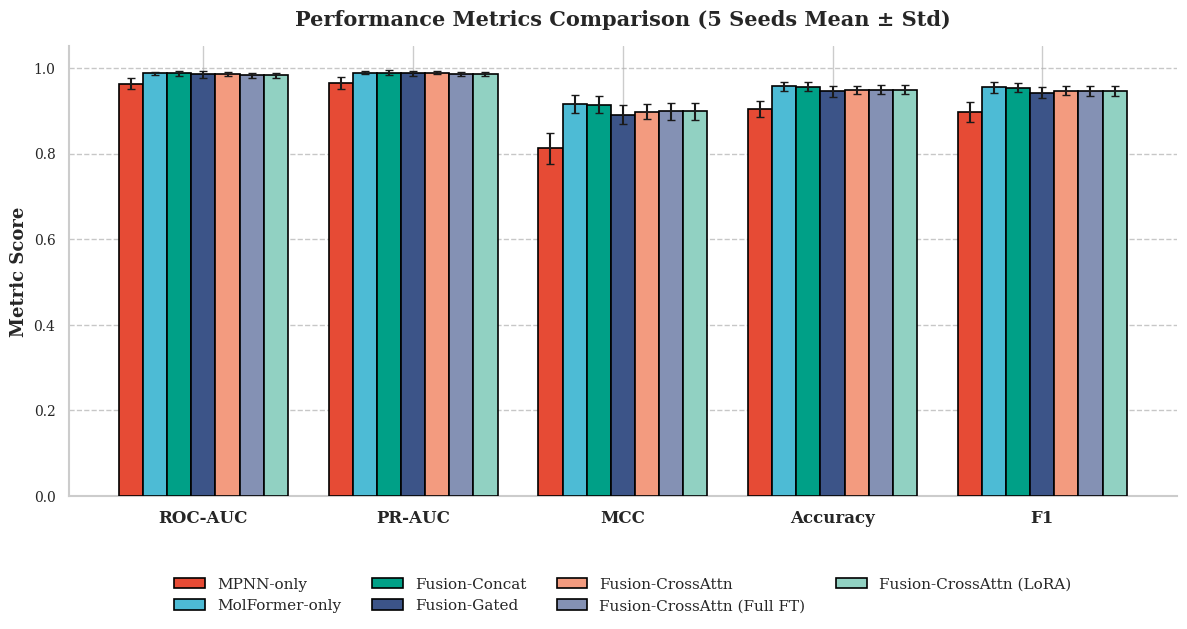


🏆 FINAL COMPREHENSIVE EXPERIMENT RESULTS SUMMARY (5 SEEDS MEAN ± STD)
  Model Configuration             ROC-AUC     PR-AUC        MCC        Acc         F1
-------------------------------------------------------------------------------------
  MPNN-only                    0.9633±0.0125 0.9653±0.0138 0.8120±0.0358 0.9045±0.0187 0.8967±0.0227
  MolFormer-only               0.9870±0.0042 0.9892±0.0035 0.9154±0.0212 0.9571±0.0110 0.9545±0.0125
  Fusion-Concat                0.9869±0.0067 0.9888±0.0054 0.9140±0.0196 0.9564±0.0098 0.9541±0.0103
  Fusion-Gated                 0.9846±0.0075 0.9872±0.0058 0.8909±0.0228 0.9449±0.0124 0.9423±0.0132
  Fusion-CrossAttn             0.9860±0.0044 0.9882±0.0034 0.8979±0.0173 0.9487±0.0088 0.9464±0.0104
  Fusion-CrossAttn (Full FT)   0.9830±0.0061 0.9861±0.0050 0.8988±0.0196 0.9487±0.0103 0.9458±0.0108
  Fusion-CrossAttn (LoRA)      0.9830±0.0061 0.9861±0.0050 0.8988±0.0196 0.9487±0.0103 0.9458±0.0108

💾 All final metrics saved to CSV file: 'results/e

In [12]:
def main():
    print("=" * 60)
    print("  EXPERIMENT START: MolFormer + MPNN (5 Seeds Sub-sampling)")
    print("=" * 60)

    print("\n[1/3] Loading MolFormer pretrained model...")
    tokenizer = AutoTokenizer.from_pretrained(MOLFORMER_NAME, trust_remote_code=True)
    molformer_base = AutoModel.from_pretrained(MOLFORMER_NAME, trust_remote_code=True).to(device)
    molformer_base.eval()
    print(f"  MolFormer loaded successfully on device: {device}")

    results_path = "results/results_summary_5seeds.pt"
    predictions_path = "results/test_predictions_5seeds.pt"
    
    if os.path.exists(results_path):
        print(f"\n💾 [Experiment Resume] Found previous experiment results file at '{results_path}'...")
        results = torch.load(results_path, weights_only=False)
    else:
        results = {}
        
    if os.path.exists(predictions_path):
        test_predictions = torch.load(predictions_path, weights_only=False)
    else:
        test_predictions = {}

    SEEDS = [42, 43, 44, 45, 46]
    models_to_run = [
        ("MPNN-only", "mpnn_only", lambda: MPNNOnly(atom_dim, bond_dim).to(device)),
        ("MolFormer-only", "molformer_only", lambda: MolFormerOnly(molformer_base).to(device)),
        ("Fusion-Concat", "fusion_concat", lambda: FusionModel(atom_dim, bond_dim, molformer_base, mode='concat').to(device)),
        ("Fusion-Gated", "fusion_gated", lambda: FusionModel(atom_dim, bond_dim, molformer_base, mode='gated').to(device)),
        ("Fusion-CrossAttn", "fusion_cross_attn", lambda: FusionModel(atom_dim, bond_dim, molformer_base, mode='cross_attention').to(device)),
        ("Fusion-CrossAttn (Full FT)", "fusion_cross_attn_full", lambda: FusionModel(atom_dim, bond_dim, AutoModel.from_pretrained(MOLFORMER_NAME, trust_remote_code=True).to(device), mode='cross_attention', tuning_mode='full').to(device)),
        ("Fusion-CrossAttn (LoRA)", "fusion_cross_attn_lora", lambda: FusionModel(atom_dim, bond_dim, AutoModel.from_pretrained(MOLFORMER_NAME, trust_remote_code=True).to(device), mode='cross_attention', tuning_mode='lora').to(device))
    ]
    
    for name, m_type, init_fn in models_to_run:
        if name not in results:
            results[name] = {}
            test_predictions[name] = {}
            
        for seed in SEEDS:
            if seed in results[name]:
                print(f"  >> [SKIPPED] {name} (Seed {seed}) already fully trained.")
                continue
                
            print(f"\n>>> Processing Model: {name} | Seed: {seed} <<<")
            set_seed(seed)
            
            # 1. Generate Split for this seed
            splits_path = f"results/data_splits_seed_{seed}.pt"
            if os.path.exists(splits_path):
                splits = torch.load(splits_path, weights_only=False)
                train_idx, val_idx, test_idx = splits['train_idx'], splits['val_idx'], splits['test_idx']
            else:
                indices = np.random.permutation(len(global_labels))
                n_train, n_val = int(0.8 * len(global_labels)), int(0.9 * len(global_labels))
                train_idx, val_idx, test_idx = indices[:n_train], indices[n_train:n_val], indices[n_val:]
                torch.save({'train_idx': train_idx, 'val_idx': val_idx, 'test_idx': test_idx}, splits_path)
            
            # 2. Build DataLoaders
            train_ds = FusionDataset([global_atoms[i] for i in train_idx], [global_bonds[i] for i in train_idx], [global_conns[i] for i in train_idx], [global_smiles[i] for i in train_idx], global_labels[train_idx])
            val_ds = FusionDataset([global_atoms[i] for i in val_idx], [global_bonds[i] for i in val_idx], [global_conns[i] for i in val_idx], [global_smiles[i] for i in val_idx], global_labels[val_idx])
            test_ds = FusionDataset([global_atoms[i] for i in test_idx], [global_bonds[i] for i in test_idx], [global_conns[i] for i in test_idx], [global_smiles[i] for i in test_idx], global_labels[test_idx])

            collate_fn = lambda batch: collate_fusion(batch, tokenizer)
            train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
            val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
            test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
            
            # 3. Train Model
            model = init_fn()
            test_metrics, probs, labels = run_experiment(model, train_loader, val_loader, test_loader, m_type, name, seed)
            
            results[name][seed] = test_metrics
            test_predictions[name][seed] = {"probs": probs, "labels": labels}
            
            torch.save(results, results_path)
            torch.save(test_predictions, predictions_path)
            
    print("\n🎨 Generating publication-quality synthesis figures (Mean ± Std)...")
    plot_all_roc_curves(test_predictions)
    plot_metrics_comparison(results)

    print("\n" + "=" * 85)
    print("🏆 FINAL COMPREHENSIVE EXPERIMENT RESULTS SUMMARY (5 SEEDS MEAN ± STD)")
    print("=" * 85)
    print(f"  {'Model Configuration':<28s} {'ROC-AUC':>10s} {'PR-AUC':>10s} {'MCC':>10s} {'Acc':>10s} {'F1':>10s}")
    print("-" * 85)
    
    summary_data = {}
    for name, seed_metrics in results.items():
        m_agg = {}
        for metric in ["ROC-AUC", "PR-AUC", "MCC", "Accuracy", "F1"]:
            vals = [seed_metrics[s][metric] for s in seed_metrics]
            m_agg[metric] = f"{np.mean(vals):.4f}±{np.std(vals):.4f}"
        summary_data[name] = m_agg
        print(f"  {name:<28s} {m_agg['ROC-AUC']:>10s} {m_agg['PR-AUC']:>10s} {m_agg['MCC']:>10s} {m_agg['Accuracy']:>10s} {m_agg['F1']:>10s}")
    print("=" * 85)
    
    pd.DataFrame(summary_data).T.to_csv("results/experiment_results_5seeds.csv")
    print("\n💾 All final metrics saved to CSV file: 'results/experiment_results_5seeds.csv'")

if __name__ == "__main__":
    main()


## 🖼️ Step 12: View Generated Plots directly in Notebook
Displays the generated academic figures inline so you can instantly check the results and download them for your paper.

1. ROC Curves Comparison (roc_curves_comparison.png):


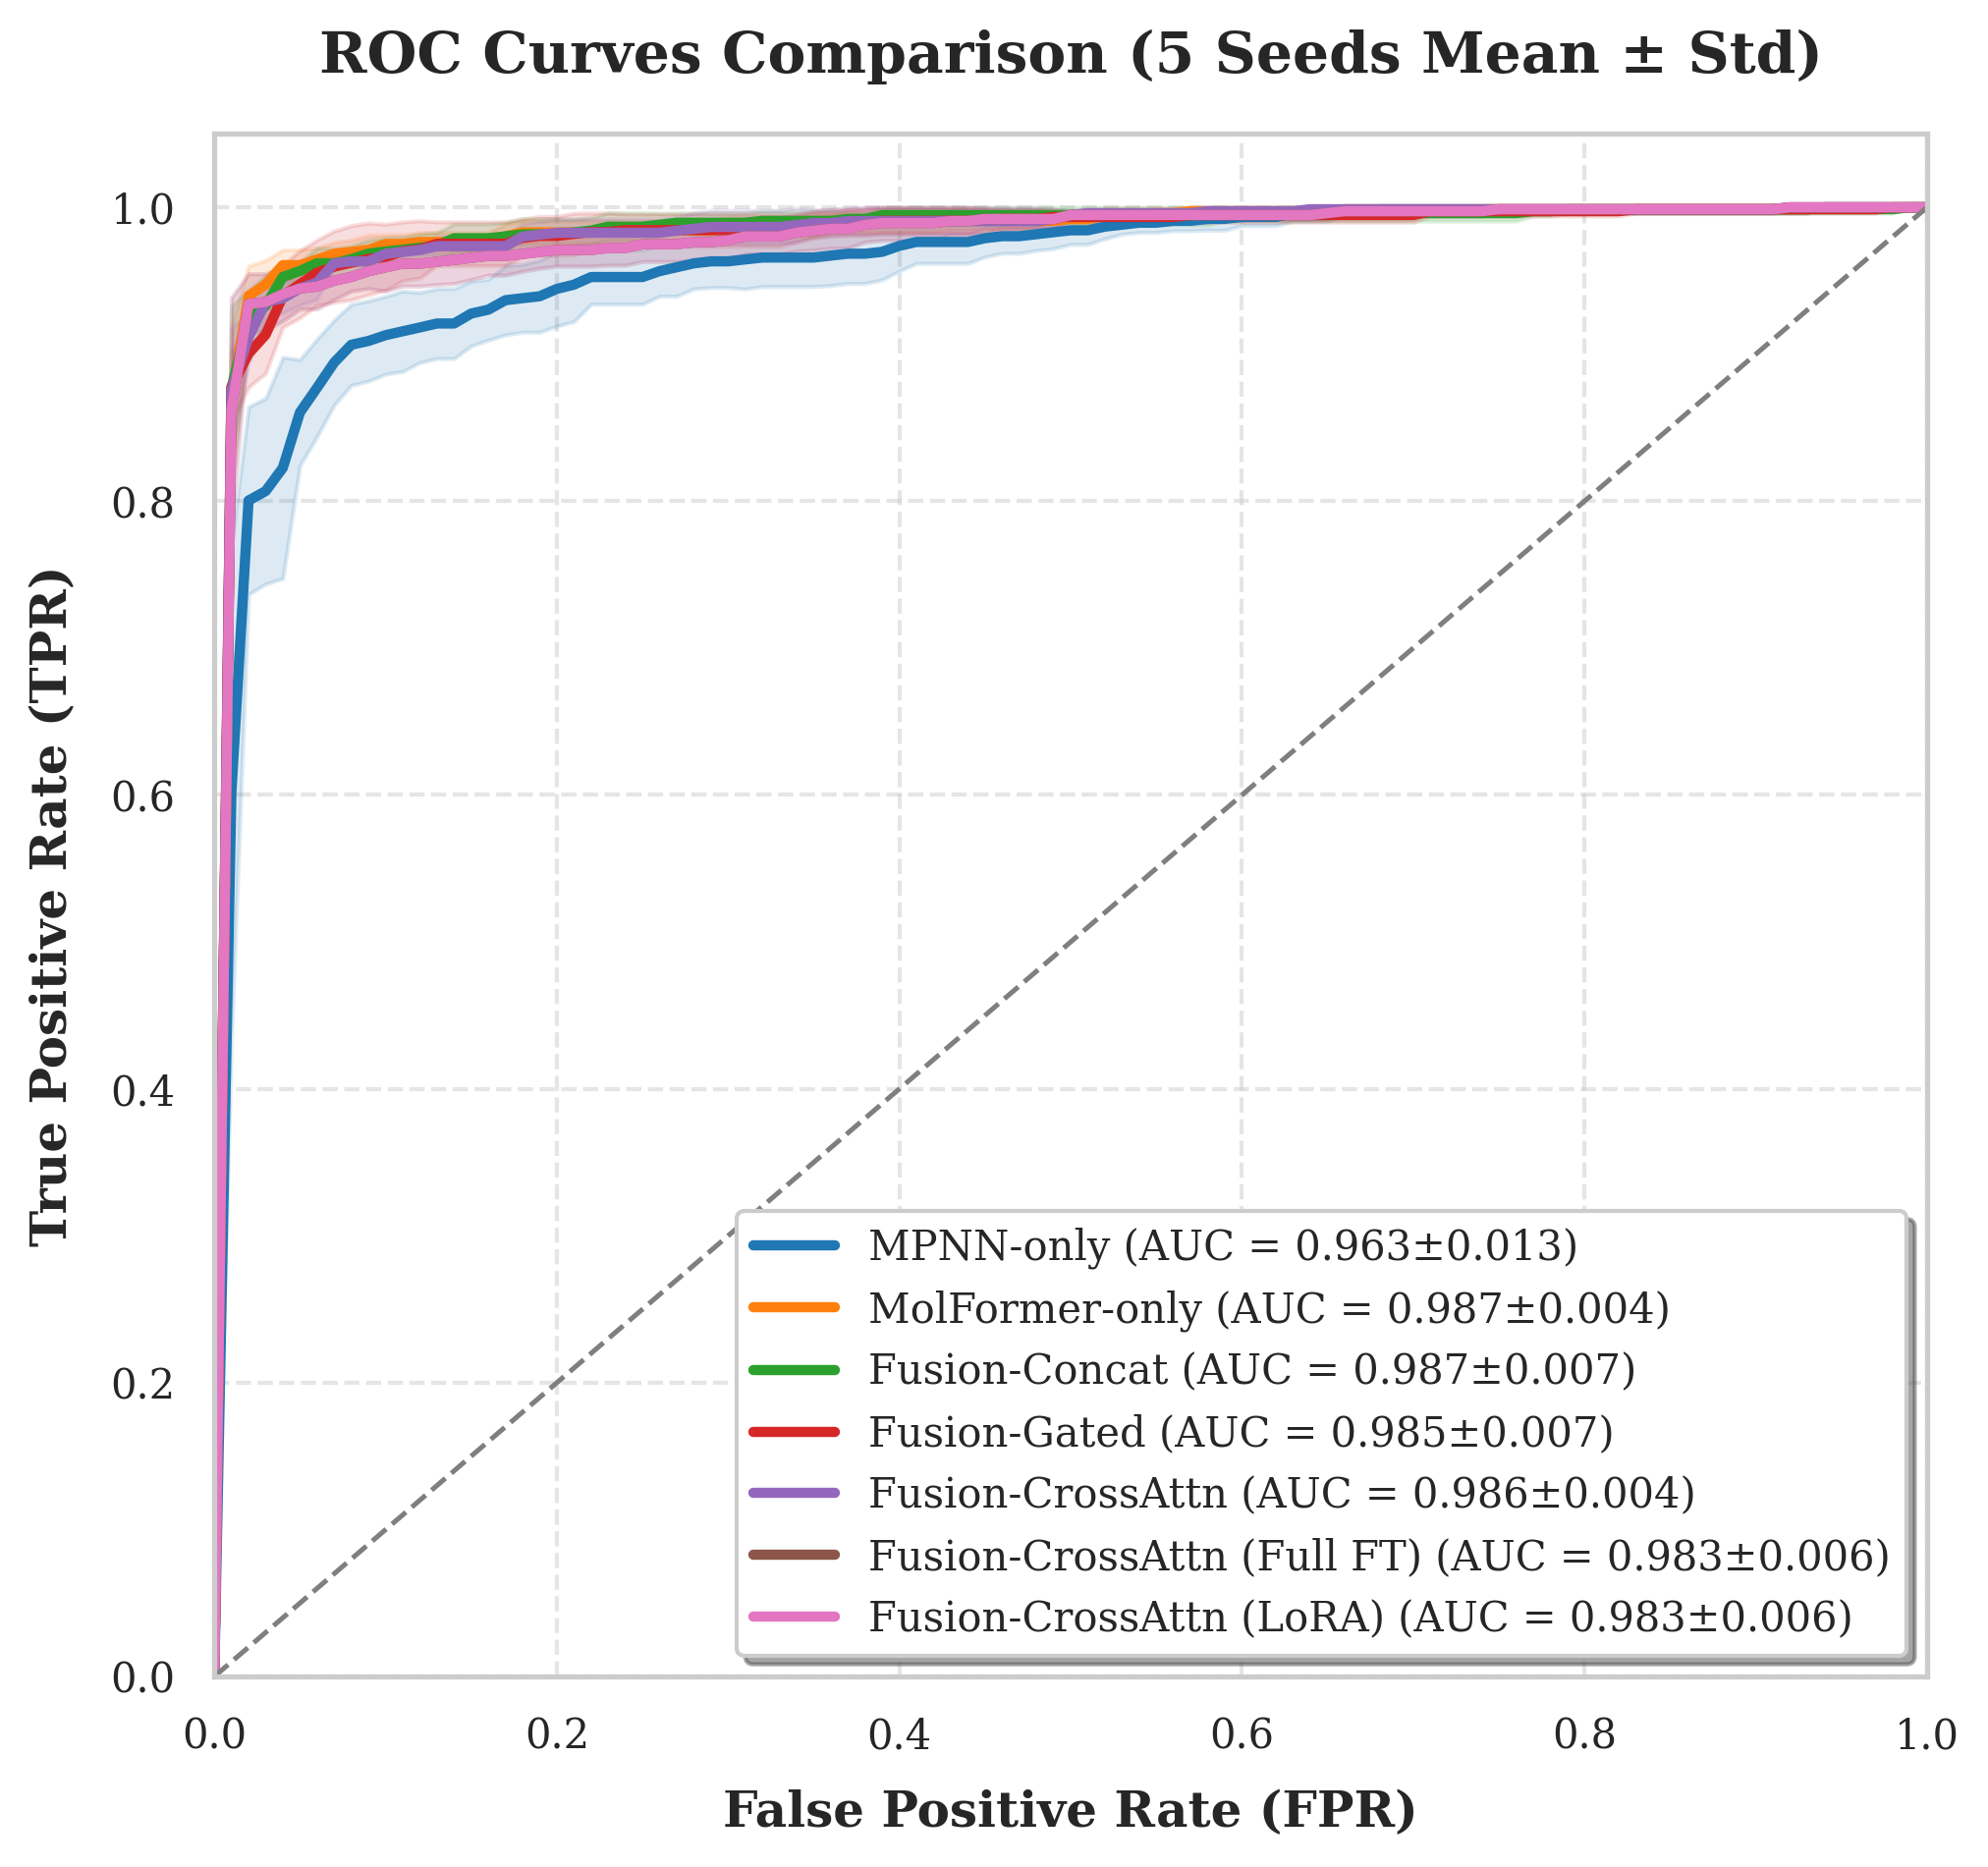


2. Multi-Metric Side-by-Side Bar Chart (metrics_comparison.png):


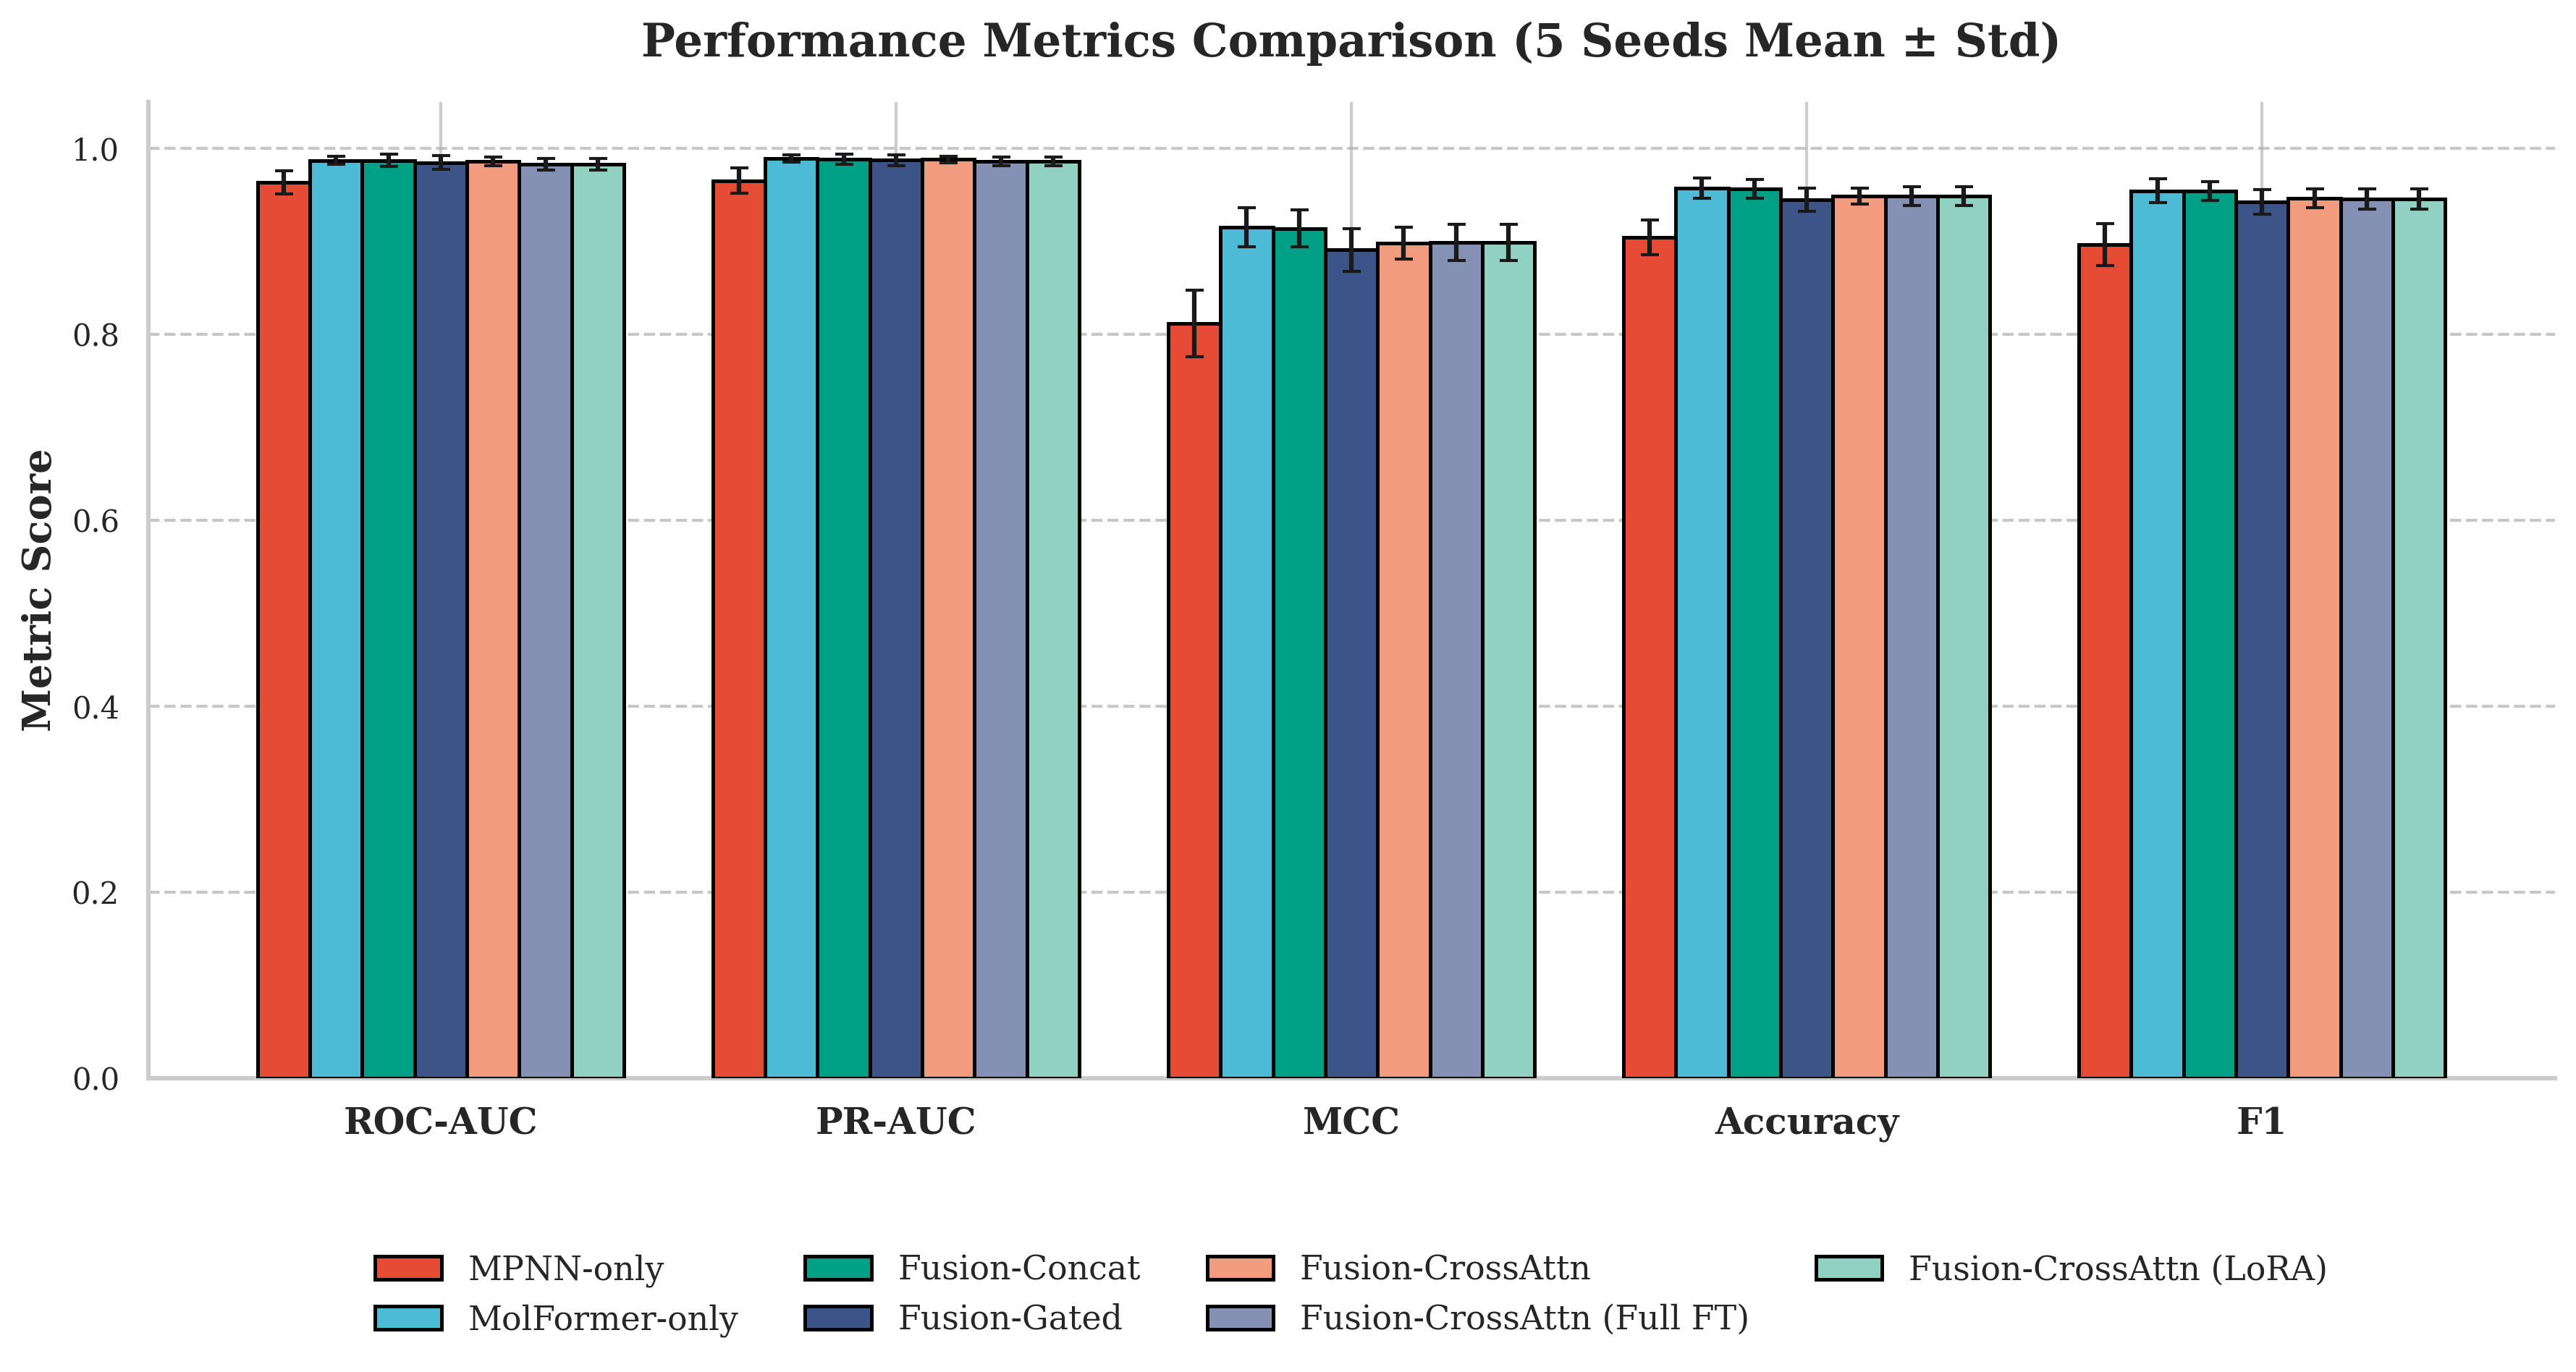


3. Best Model Training & Convergence History (e.g. fusion_cross_attn_history.png):


In [13]:
from IPython.display import Image, display

print("1. ROC Curves Comparison (roc_curves_comparison.png):")
if os.path.exists("results/plots/roc_curves_comparison.png"):
    display(Image(filename="results/plots/roc_curves_comparison.png"))

print("\n2. Multi-Metric Side-by-Side Bar Chart (metrics_comparison.png):")
if os.path.exists("results/plots/metrics_comparison.png"):
    display(Image(filename="results/plots/metrics_comparison.png"))

print("\n3. Best Model Training & Convergence History (e.g. fusion_cross_attn_history.png):")
if os.path.exists("results/plots/fusion_cross_attn_history.png"):
    display(Image(filename="results/plots/fusion_cross_attn_history.png"))